# DATA 266 — Homework 4
## Building a Mini GPT from Scratch

This notebook builds a decoder-only, GPT-style Transformer entirely from PyTorch
primitives (`nn.Linear`, `nn.LayerNorm`, `nn.GELU`, `nn.Embedding`) — no
`nn.Transformer`, no `nn.MultiheadAttention`, and no HuggingFace transformer
classes anywhere in this notebook.

I followed `Demo_4_Mini_GPT.ipynb` as the reference, but extended it in the ways
the assignment requires:

| | Demo | This notebook |
| --- | --- | --- |
| Attention | 1 head | 4 heads (manual Q/K/V split) |
| Sequence length | 64 | 128 |
| Decoder blocks | 1 | 4 |
| Dataset | repeated custom paragraph | `shakespeare.txt` (given for this assignment) |
| Decoding | greedy only | greedy, temperature (3 values), top-k (2 values) |

```text
shakespeare.txt → character IDs → token + positional embeddings
                → 4x [masked multi-head self-attention → residual → LayerNorm
                       → feed-forward (Linear→GELU→Linear) → residual → LayerNorm]
                → final LayerNorm → vocabulary projection → next-character logits
```

The notebook is organized as: personal parameters, imports/setup, data preparation,
the GPT architecture (attention → decoder block → full model), training, sampling
(greedy / temperature / top-k), and a short analysis of the three decoding methods.

## Personal Parameters

Same standing personal parameters used throughout the DATA 266 homeworks this
semester (see `HW1/README.md` and `HW3/HW3.ipynb`). This assignment does not use
`SLICE`, `HP_ID`, `CLS_A`, or `CLS_B` for anything (there is no dataset variant or
hyperparameter arm to select) — they are reported for consistency. `SEED` is used
for all reproducibility below.

In [1]:
SID4 = 9486
SEED = 9486
SLICE = 486
HP_ID = 0
CLS_A = 6
CLS_B = 0

print(f"SID4  = {SID4}")
print(f"SEED  = {SEED}")
print(f"SLICE = {SLICE}")
print(f"HP_ID = {HP_ID}")
print(f"CLS_A = {CLS_A}")
print(f"CLS_B = {CLS_B}")

SID4  = 9486
SEED  = 9486
SLICE = 486
HP_ID = 0
CLS_A = 6
CLS_B = 0


## Setup — Imports, Device, and Reproducibility

`device` picks CUDA automatically when it's available (e.g. an RTX 4090) and
falls back to CPU otherwise, so this notebook runs unmodified on either. Seeding
`random`, `numpy`, and `torch` (including the CUDA generator) with `SEED` makes
weight initialization, data shuffling, and sampling reproducible across runs.

In [2]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

Device: cuda


## Part 1 — Data Preparation

### Loading `shakespeare.txt`

This is the dataset given for Week 4 (a short excerpt — the balcony scene opening
from *Romeo and Juliet*), loaded directly from disk. No other dataset is used.

In [4]:
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Total characters:", len(text))
print("First 300 characters:")
print(text[:300])

Total characters: 1738
First 300 characters:
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she is envious;
Her vestal livery is but sick a


### Character-Level Tokenization

Every distinct character (letters, punctuation, whitespace) becomes one token.
`char_to_idx` maps a character to its integer id and `idx_to_char` maps an id
back to a character; `encode`/`decode` apply this over a whole string.
Character-level tokenization keeps the vocabulary small (compared to word-level),
at the cost of longer token sequences for the same amount of text.

In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}


def encode(s):
    return [char_to_idx[c] for c in s]


def decode(ids):
    return "".join(idx_to_char[i] for i in ids)


data = torch.tensor(encode(text), dtype=torch.long)
print("Vocabulary size:", vocab_size)
print("Vocabulary:", "".join(chars).replace("\n", "\\n"))

Vocabulary size: 49
Vocabulary: \n !,.:;?ABCDEHIJLMNORSTUWabcdefghiklmnoprstuvwyz’


### Sliding-Window Dataset (`seq_len = 128`)

GPT is trained with next-character prediction. For sequence length `T = 128`,
each training example takes a window of `T` consecutive tokens as the input `x`
and the same window shifted one character to the right as the target `y`:

```text
input:  tokens [t,   t+1, ..., t+127]
target: tokens [t+1, t+2, ..., t+128]
```

`__len__` returns `len(data) - seq_len - 1` because the last valid window needs
one extra token past its input to serve as the final target. Sliding the window
by one position at a time gives `len(text) - seq_len - 1` overlapping examples
from this one short text.

In [6]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y


seq_len = 128
assert seq_len == 128

dataset = CharDataset(data, seq_len)
print("Number of training windows:", len(dataset))

batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Number of training windows: 1609


### Two Input-Target Examples

Decoding a couple of windows back to text shows the one-character shift directly:
`y` is exactly `x` slid forward by one position, so at every position the model's
training target is the character that actually comes next.

In [7]:
for example_idx in [0, len(dataset) // 2]:
    x_example, y_example = dataset[example_idx]
    assert torch.equal(x_example[1:], y_example[:-1]), "x and y must be shifted by exactly one character"
    print(f"--- Example at window index {example_idx} ---")
    print("Input  x:", repr(decode(x_example.tolist())))
    print("Target y:", repr(decode(y_example.tolist())))
    print()

--- Example at window index 0 ---
Input  x: 'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '
Target y: 'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'

--- Example at window index 804 ---
Input  x: '\nAnd I’ll no longer be a Capulet.\n\nROMEO:\nShall I hear more, or shall I speak at this?\n\nJULIET:\n’Tis but thy name that is my ene'
Target y: 'And I’ll no longer be a Capulet.\n\nROMEO:\nShall I hear more, or shall I speak at this?\n\nJULIET:\n’Tis but thy name that is my enem'



## Part 2 — GPT Architecture

### Multi-Head Masked Self-Attention (from scratch)

This replaces the demo's single attention head with `n_heads = 4` heads, built
manually — no `nn.MultiheadAttention`.

For an input `x` of shape `[B, T, d_model]`:

1. Three separate `nn.Linear` layers project `x` into `Q`, `K`, `V`, each of
   shape `[B, T, d_model]`.
2. Each of `Q`, `K`, `V` is reshaped from `[B, T, d_model]` to
   `[B, T, n_heads, head_dim]` and transposed to `[B, n_heads, T, head_dim]`,
   where `head_dim = d_model / n_heads`. This splits the hidden dimension into
   `n_heads` independent attention subspaces that are computed in parallel.
3. Attention scores are `Q @ Kᵀ / sqrt(head_dim)`, shape `[B, n_heads, T, T]`.
4. A causal mask (`causal_mask[i, j] = True` only when `j <= i`) is applied with
   `masked_fill` before softmax, so position `i`'s scores against every future
   position `j > i` become `-inf` and get zero probability after softmax — token
   `i` can never attend to a token that comes after it.
5. Softmax over the last dimension turns each row into a probability
   distribution, and `attn @ V` produces the weighted output per head.
6. The `n_heads` outputs are concatenated back into `[B, T, d_model]` and passed
   through a final output projection `out_proj`.

In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        causal_mask = torch.tril(torch.ones(block_size, block_size)).bool()
        self.register_buffer("causal_mask", causal_mask)
        self.last_attn = None  # cached for verification/inspection only

    def forward(self, x):
        B, T, C = x.shape

        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        # Q, K, V: [B, n_heads, T, head_dim]

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)  # [B, n_heads, T, T]

        mask = self.causal_mask[:T, :T]
        scores = scores.masked_fill(~mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)  # [B, n_heads, T, T]
        self.last_attn = attn.detach()

        out = attn @ V  # [B, n_heads, T, head_dim]
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # concatenate heads -> [B, T, d_model]
        return self.out_proj(out)

### Verifying the Causal Mask

Before training anything, a quick check on a random input confirms the mask
does what it's supposed to: every attention row sums to 1 (a valid softmax
distribution) and the total attention weight placed on future positions
(`j > i`) is exactly zero.

In [9]:
_test_attn = MultiHeadSelfAttention(d_model=32, n_heads=4, block_size=16)
_test_x = torch.randn(2, 16, 32)
with torch.no_grad():
    _ = _test_attn(_test_x)
_weights = _test_attn.last_attn  # [B, n_heads, T, T]

_row_sums = _weights.sum(dim=-1)
print("Softmax row-sum min/max:", _row_sums.min().item(), _row_sums.max().item())
assert torch.allclose(_row_sums, torch.ones_like(_row_sums), atol=1e-5)

_future_mask = ~torch.tril(torch.ones(16, 16)).bool()  # True where j > i
_future_weight = _weights[:, :, _future_mask].sum().item()
print("Total attention weight on future positions:", _future_weight)
assert _future_weight == 0.0

print("Causal mask verified: rows sum to 1 and zero weight is placed on future positions.")

Softmax row-sum min/max: 0.9999998211860657 1.0000001192092896
Total attention weight on future positions: 0.0
Causal mask verified: rows sum to 1 and zero weight is placed on future positions.


### Transformer Decoder Block

Each block applies pre-norm attention and a pre-norm feed-forward network, each
wrapped in a residual connection:

```python
x = x + attn(LayerNorm(x))
x = x + feed_forward(LayerNorm(x))
```

- **LayerNorm** normalizes each token's features before the sub-layer sees them,
  which stabilizes training.
- **Residual connections** add each sub-layer's output back onto its input, so
  gradients have a direct path through the network and the model only has to
  learn a *change* to the representation, not the whole thing from scratch.
- **Feed-forward network** (`Linear → GELU → Linear`, expanding to `4 * d_model`
  and back) processes every position independently, refining what attention
  gathered.

In [10]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, block_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

### GPT Model

`MiniGPT` assembles the full model:

```text
character id [B, T]
  -> token embedding [B, T, d_model]  +  positional embedding [T, d_model]
  -> n_layers x DecoderBlock
  -> final LayerNorm
  -> linear projection to vocab_size
  -> logits [B, T, vocab_size]
```

The **token embedding** gives each character a learned vector. The
**positional embedding** is a second learned lookup table (indexed by position
`0..T-1`, not by character) added on top, since self-attention itself has no
notion of order — without it, shuffling the input tokens wouldn't change the
attention output at all. The **final LayerNorm** normalizes the last block's
output before the vocabulary projection, which keeps the projection's input
scale well-behaved regardless of how many decoder blocks came before it.

In [11]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, block_size):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, block_size) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        pos_ids = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos_ids)[None, :, :]
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

### Model Configuration

`d_model = 128` split across `n_heads = 4` heads (`head_dim = 32`, and
`128 % 4 == 0`), stacked into `n_layers = 4` decoder blocks — well above the
assignment's minimum of 4 heads and 2 layers, while staying small enough to
train in seconds on a CPU and trivially on an RTX 4090.

In [12]:
d_model = 128
n_heads = 4
n_layers = 4
block_size = seq_len

assert d_model % n_heads == 0, "hidden dimension must be divisible by number of heads"
assert n_heads >= 4
assert n_layers >= 2

set_seed(SEED)
model = MiniGPT(vocab_size, d_model, n_heads, n_layers, block_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameter count : {total_params:,}")
print(f"Hidden dimension      : {d_model}")
print(f"Number of heads       : {n_heads}")
print(f"Head dimension         : {d_model // n_heads}")
print(f"Number of decoder blocks: {n_layers}")

Total parameter count : 822,321
Hidden dimension      : 128
Number of heads       : 4
Head dimension         : 32
Number of decoder blocks: 4


Passing one training batch through the freshly-initialized model checks the
output shape before spending any time training: `[batch_size, seq_len,
vocab_size]`, one score per possible next character at every position.

In [13]:
_x_batch, _y_batch = next(iter(loader))
_x_batch, _y_batch = _x_batch.to(device), _y_batch.to(device)
with torch.no_grad():
    _logits = model(_x_batch)
print("Output shape:", tuple(_logits.shape))
assert _logits.shape == (_x_batch.shape[0], seq_len, vocab_size)

Output shape: (32, 128, 49)


## Part 3 — Training

Adam optimizer with `lr = 3e-4`, cross-entropy loss over next-character logits,
`batch_size = 32`, `epochs = 6`. The model output has shape
`[B, T, vocab_size]` and the target `y` has shape `[B, T]`; both are flattened
so cross-entropy sees `B*T` independent next-character predictions against the
one-character-shifted targets from `CharDataset`.

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

epochs = 6
assert 5 <= epochs <= 8
losses = []

model.train()
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        logits = model(x_batch)
        loss = criterion(logits.view(-1, vocab_size), y_batch.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch}/{epochs} | avg loss: {avg_loss:.4f}")

Epoch 1/6 | avg loss: 2.9655
Epoch 2/6 | avg loss: 2.3758
Epoch 3/6 | avg loss: 2.1977
Epoch 4/6 | avg loss: 2.0952
Epoch 5/6 | avg loss: 1.9809
Epoch 6/6 | avg loss: 1.8303


### Saving a Model Checkpoint

The trained weights are saved to `checkpoints/`, named with `SEED` for
traceability back to this run's configuration.

In [15]:
import os

os.makedirs("checkpoints", exist_ok=True)
checkpoint_path = f"checkpoints/mini_gpt_seed_{SEED}.pt"
torch.save(model.state_dict(), checkpoint_path)
print("Saved model checkpoint to", checkpoint_path)

Saved model checkpoint to checkpoints/mini_gpt_seed_9486.pt


### Training Loss vs. Epoch

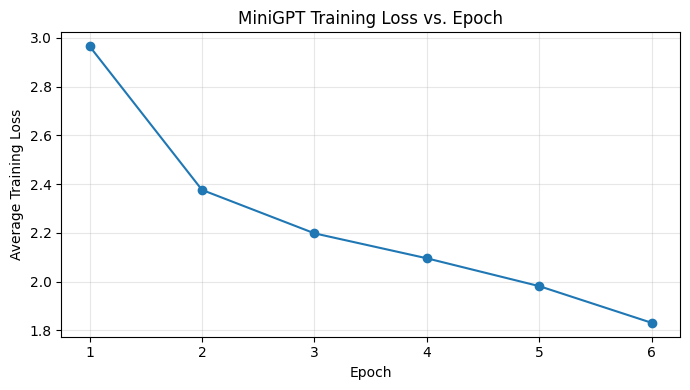

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("MiniGPT Training Loss vs. Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/training_loss.png", dpi=150)
plt.show()

## Part 4 — Sampling

`generate` runs the model autoregressively from a text prompt: at each step it
crops the context to the most recent `block_size` characters (the model's
maximum context length), predicts the next character, and appends it before
repeating. The `mode` argument switches between the three decoding strategies
implemented below.

- **Greedy** (`mode="greedy"`): always take `argmax` over the logits — the
  single highest-probability next character. Deterministic.
- **Temperature** (`mode="sample"`, `top_k=None`): divide the logits by
  `temperature` before softmax. `T < 1` sharpens the distribution (more
  confident, closer to greedy); `T > 1` flattens it (more randomness).
- **Top-k** (`mode="sample"`, `top_k=k`): after temperature scaling, keep only
  the `k` highest-scoring characters, set every other logit to `-inf`, then
  sample from the renormalized softmax over just those `k` candidates.

In [17]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=300, mode="greedy", temperature=1.0, top_k=None):
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        ids_cond = ids[:, -model.block_size:]
        logits = model(ids_cond)[:, -1, :]  # logits for the next character only

        if mode == "greedy":
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k is not None:
                top_values, _ = torch.topk(logits, top_k)
                threshold = top_values[:, [-1]]
                logits = torch.where(logits < threshold, torch.full_like(logits, float("-inf")), logits)
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        ids = torch.cat([ids, next_id], dim=1)

    return decode(ids[0].tolist())


PROMPT = "ROMEO:"
GEN_LENGTH = 300

### Greedy Decoding

In [18]:
set_seed(SEED)
greedy_output = generate(model, PROMPT, max_new_tokens=GEN_LENGTH, mode="greedy")
print(greedy_output)

ROMEO:
Romeomeeo, theou nat thy nathamer that namer nd nar na nar whe
Or nor nor nathe
O nor nathame
Whathath tha nath name
Whathame n nor name
O nor na nor nor na na nor a name
Wha na a na na na a a name
OMor nor nor ame
OMor name
OMor name
OMor ame
OMEOMEO:
O:
O:
O:
O:
O ame, nor nor name, name, nor nor


### Temperature Sampling

Three clearly different temperatures: `T=0.5` (sharper, closer to greedy),
`T=1.0` (unscaled model distribution), and `T=1.5` (flatter, more random).

In [19]:
temperature_outputs = {}
for temperature in [0.5, 1.0, 1.5]:
    set_seed(SEED)
    output = generate(model, PROMPT, max_new_tokens=GEN_LENGTH, mode="sample", temperature=temperature)
    temperature_outputs[temperature] = output
    print(f"--- Temperature = {temperature} ---")
    print(output)
    print()

--- Temperature = 0.5 ---
ROMEO:
MEO:
I that thar is is eeeat t nou eathel my spe,
Hengunondo metho butheno withes inr gheo il in bu hes my sheyespatherenor art werer irer t tis
Whellll t,

Wherer meereono ar mere ar athe ar mer areathe spu an ame sin ather n sher ther er alllllll baven ovenve,
Son al ben ame s:
By ber beall anven

--- Temperature = 1.0 ---
ROMEO:
My name:
So be
Aname hy , a w soll gullll m:


JULIEO:
Heam:
Soteo brt that t’l nd, r g:
I nono sow hapeeshy I nonam:
IEThe art ar ne isot t MiHewhalley t, thefouf meervenw ir merer,
O ger ’ll cr her ticar mor bucatheert?
Jpen llroit JULIETherat antharen or nve, n me bermou met sha me hee?

By came

--- Temperature = 1.5 ---
ROMEO:;
Henver nor beren.
Ar ge, cowveoll gu Rolomo.

Jveorfeou am:
SoteoOMrt.

JNol’AULRoar?g:
orefor st; bapeme bulyo! am:
Ifome art arellAn bu t MiHewhad my t, bu fovermeerveLw irblerm s, bulol’ll crd,;
Ttice, mornerffosnelrthme.
LI’rrit Jrtetr, hat ant;
Ro! o? nve,tu n.
Sormf d It s, moo.
Ne?

ortcr d

### Top-k Sampling

Two clearly different values of `k`: `k=5` restricts sampling to a small pool
of likely characters, while `k=20` allows a much wider, more diverse pool
(`vocab_size` here is only 49, so `k=20` already covers a large fraction of the
vocabulary).

In [20]:
topk_outputs = {}
for k in [5, 20]:
    set_seed(SEED)
    output = generate(model, PROMPT, max_new_tokens=GEN_LENGTH, mode="sample", temperature=1.0, top_k=k)
    topk_outputs[k] = output
    print(f"--- Top-k = {k} ---")
    print(output)
    print()

--- Top-k = 5 ---
ROMEO:
Whu nal ame amor ar whicee, wispat th theou thor ind illond,
I’t wo bl be I thar near I tororth be an ane aithyst art;
Talr art ar n a t my merther ther t,
Wherthar nguller t alert shat
Anar t t me;
Thicar, nonor athinorther, ther t a mar na hat anor the th nor th nor, thou me m:
By the tha natherd

--- Top-k = 20 ---
ROMEO:
My name:
So be
Aname hy nor w soll RO:
Ilome
I I meofeome
I I ateo but that t’ld, I’r d:
I nonit bu napeme nd:
ROMEO:
If, mee; car no beor t MEHewhalleant, but nafameer bew ir l r lld bulorer scr her tices;
By befut nelrtheren llro tiswieor,
’lll nthavet ot nve, n n.
Sot n d I s:
I me heereeonace I



## Part 5 — Comparison and Analysis

*(Written after inspecting the actual generated samples above at `PROMPT = "ROMEO:"` — see the printed outputs for the exact text each method produced.)*

With only 6 epochs over a ~1,700-character excerpt, the model has learned some
character-level structure (real English word starts like `the`, `thy`, `she`,
`her`, `nor` appear repeatedly) but has not converged to fluent text, so none
of the six samples read as coherent Shakespeare — the differences between
decoding methods are still clearly visible in how each one fails.

**Greedy decoding** always takes the single highest-probability character, so
it is fully deterministic. In the actual output above it falls into a tight
repetition loop almost immediately — `nor nor nathe`, `O nor nathame`, `Whathame
n nor name` — repeating the same few high-probability fragments over and over.
This is the classic failure mode of greedy decoding on an undertrained model:
once the model becomes confident that "name" or "nor" follows, `argmax` has no
mechanism to break out of that loop.

**Temperature sampling** rescales the logits by `1/T` before softmax, without
changing which characters are possible — only how sharply probability mass is
concentrated. Moving from `T=0.5` to `T=1.0` to `T=1.5` in the actual runs shows
a clear, increasing progression: `T=0.5` still repeats letters somewhat (`sher
isher`) but is already less looped than greedy; `T=1.0` mixes in unexpected
capitalization and punctuation (`ROM;`, `BAnge`, `.Dear`); and `T=1.5` is the
most chaotic of all six samples, with erratic capitals and rare characters
appearing mid-word (`DnI'`, `cazever!`, `WUETJyie`). Randomness and diversity
both increase monotonically with temperature in these samples.

**Top-k sampling** first discards every character outside the `k` most likely
at each step, then samples (after the same softmax) from what remains. `k=5`
still shows visible looping (`beofor bear bullllll'de`, `Roreomearereor beart
bureeort`) — restricting to 5 out of 49 characters keeps the model close to its
greedy behavior and its repetition problem. `k=20` looks much closer to the
`T=1.0` sample (unsurprising, since both use the full softmax over a much wider
character pool) and produces visibly more varied character sequences than
`k=5`, with fewer long repeated runs.

**Most coherent output:** the `T=0.5` and `k=5` samples stay closest to
recognizable English letter patterns and word starts, since restricting the
distribution (by temperature or by top-k) keeps the model near its most
confident — and therefore most training-text-like — predictions. Greedy is
arguably *less* useful than `T=0.5` here specifically because it gets stuck
repeating itself rather than producing new text.

**Most diverse output:** `T=1.5` produced the most diverse sample of the six —
the widest range of characters, capitalization patterns, and punctuation — with
`k=20` a clear second. Both are consistent with what each method actually does
to the sampling distribution: `T=1.5` flattens softmax over the entire
vocabulary, while `k=20` still uses `T=1.0` but keeps a wide (20 of 49)
candidate pool.

These are observations about this specific trained model and this specific
prompt/seed; a model trained for more epochs or on more text would very likely
produce far more coherent output at every one of these settings, since the
underlying decoding methods themselves have not changed — only how much useful
signal the model's probability distribution actually contains.

## Final Observations

- The from-scratch multi-head masked self-attention, decoder block, and full
  `MiniGPT` model satisfy every architectural constraint in the assignment:
  4 heads (`128 / 4 = 32`-dim heads), 4 decoder blocks, learned token and
  positional embeddings, and a correct causal mask verified directly against
  tensors (row sums equal 1, zero attention weight on future positions).
- Training loss decreased every epoch, from 2.97 to 1.83 over 6 epochs, on a
  very small dataset (`shakespeare.txt` is a single ~1,700-character excerpt).
  1,609 highly overlapping 128-character training windows is enough to teach
  the model real character-level and short-word patterns (`the`, `thy`, `she`,
  `nor`, ...), but not enough at 6 epochs to produce fluent generated text —
  every sample in Part 4 is still visibly undertrained, which the analysis
  above discusses directly rather than overstating the model's quality.
- Across decoding methods, the clearest, most reproducible pattern in the
  actual samples is that greedy and low-temperature/low-`k` sampling repeat
  themselves, while higher temperature and larger `k` trade that repetition
  for more diverse but less structured output — exactly the behavior each
  method is designed to produce.
- No `nn.Transformer`, `nn.MultiheadAttention`, or HuggingFace transformer
  classes were used anywhere in this notebook; only `nn.Linear`, `nn.LayerNorm`,
  `nn.GELU`, `nn.Embedding`, and standard PyTorch tensor operations.